## Replicability Check

The notebook was tested in a clean virtual environment (venv_test).

Steps performed:
- Created a new virtual environment
- Installed dependencies using requirements.txt
- Successfully executed all cells without errors

Tested by: Haibo Yuan



# **Tidying**

Part of the data engineering process is data cleaning and tidying. What is done in those two processes, is trying to make the data more readable, and complete. This makes much easier to analyze, visualize, and train the data.


## **Data Tidying**

Making the data more organized, and readable is the result of applying data tidying. 

In this section two main pandas functions are used in data tidying those are `melt` and `pivot_table`.

Let's start by taking a look at the below dataframe, which represents the income ranges based on religion. This is part of the PEW research, which is famous in the US for conducting pollings and surveys on citizens.

When the following are satisfied:


1. Each variable forms a column
2. Each observation forms a row
3. Each type of observational unit forms a table

We can then say that our dataset is *tidy*.

First we need to import pandas to read csv datasets.

In [1]:
import pandas as pd
import numpy as np


### **PEW Research Dataset**

1. Start by Importing the dataset into a pandas dataframe.

In [2]:
# Load the PEW Research dataset into a pandas DataFrame
df_pew = pd.read_csv("../CSVs/pew-raw.csv")


2. Observe the dataset using the `loc`, `iloc`, `head`, or `tail` approaches

In [3]:
# Display the first 5 rows of the dataset
# This helps us quickly understand the overall structure and column layout
df_pew.head()


,religion,<$10k,$10-20k,$20-30k,$30-40k,$40-50k,$50-75k
0,Agnostic,27,34,60,81,76,137
1,Atheist,12,27,37,52,35,70
2,Buddhist,27,21,30,34,33,58
3,Catholic,418,617,732,670,638,1116
4,Dont know/refused,15,14,15,11,10,35


In [4]:
# Display the last 5 rows of the dataset
# Check if the dataset ends cleanly.
df_pew.tail()


,religion,<$10k,$10-20k,$20-30k,$30-40k,$40-50k,$50-75k
5,Evangelical Prot,575,869,1064,982,881,1486
6,Hindu,1,9,7,9,11,34
7,Historically Black Prot,228,244,236,238,197,223
8,Jehovahs Witness,20,27,24,24,21,30
9,Jewish,19,19,25,25,30,95


In [5]:
# Select the first 3 rows and first 5 columns using integer-location indexing
df_pew.iloc[0:3, 0:5]


,religion,<$10k,$10-20k,$20-30k,$30-40k
0,Agnostic,27,34,60,81
1,Atheist,12,27,37,52
2,Buddhist,27,21,30,34


In [6]:
# Select rows using label-based indexing
df_pew.loc[:, df_pew.columns[:5]].head()


,religion,<$10k,$10-20k,$20-30k,$30-40k
0,Agnostic,27,34,60,81
1,Atheist,12,27,37,52
2,Buddhist,27,21,30,34
3,Catholic,418,617,732,670
4,Dont know/refused,15,14,15,11


***What does not seem right in the above dataframe?***

By examining the dataset using `head()`, `tail()`, and indexing methods,
we can identify a few issues with its current structure:

* The income ranges (such as `<$10k`, `$10–20k`, `$20–30k`, etc.) are stored as column names instead of values.
* Each row contains multiple income-related values, making it harder to analyze or visualize the data.
* Variables are spread across multiple columns rather than being organized into a single key-value structure.





3. Try to make the column headers represent a variable not a value. For that, use the `melt` function.

In [7]:
# - 'religion' is kept as the identifier variable
# - Income ranges are converted from column headers
#   into values under a new column called 'income_range'


df_pew_long = pd.melt(
    df_pew,
    id_vars="religion",
    var_name="income_range",
    value_name="count"
)

# Display the first few rows of the reshaped dataset
df_pew_long.head()


,religion,income_range,count
0,Agnostic,<$10k,27
1,Atheist,<$10k,12
2,Buddhist,<$10k,27
3,Catholic,<$10k,418
4,Dont know/refused,<$10k,15


In [8]:
# Check the shape of the dataset before and after reshaping
print("Original shape:", df_pew.shape)
print("Reshaped shape:", df_pew_long.shape)


Original shape: (10, 7)
Reshaped shape: (60, 3)


### **Billboard Dataset**

This dataset outlines data about the top hit songs on the Billboard list and the week from entrance that it was in the billboard with the ranking.

1. Read the dataset and store it in a pandas dataframe. Note that the usual utf-8 encoding does not work on this dataset. The reason behind this is that there might be characters that are not supported by `utf-8`.

The suggestion is to use for this dataset `unicode_escape` encoding. (converts all non-ASCII characters into their \uXXXX representations)

In [9]:
# Load the Billboard dataset into a pandas DataFrame

df_billboard = pd.read_csv(
    "../CSVs/billboard.csv",
    encoding="unicode_escape"
)


The dataset is read using the `unicode_escape` encoding to handle special
characters that are not supported by the default UTF-8 encoding.


2. Observe the first few rows of the dataset.

In [10]:
# Display the first few rows to verify the dataset was loaded correctly
df_billboard.head()

,year,artist.inverted,track,time,genre,date.entered,date.peaked,x1st.week,x2nd.week,x3rd.week,...,x67th.week,x68th.week,x69th.week,x70th.week,x71st.week,x72nd.week,x73rd.week,x74th.week,x75th.week,x76th.week
0,2000,Destiny's Child,Independent Women Part I,3:38,Rock,2000-09-23,2000-11-18,78,63.0,49.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000,Santana,"Maria, Maria",4:18,Rock,2000-02-12,2000-04-08,15,8.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,Savage Garden,I Knew I Loved You,4:07,Rock,1999-10-23,2000-01-29,71,48.0,43.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,Madonna,Music,3:45,Rock,2000-08-12,2000-09-16,41,23.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,"Aguilera, Christina",Come On Over Baby (All I Want Is You),3:38,Rock,2000-08-05,2000-10-14,57,47.0,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


***What is wrong with the above dataset?***

* The dataset contains a large number of columns representing weekly rankings
  (such as `x1st.week`, `x2nd.week`, `x3rd.week`, etc.), which indicates that the
  data is stored in a wide format.
* Many of the weekly ranking columns contain missing values (NaN), since not all
  songs remain on the Billboard chart for the same number of weeks.
* The week information is encoded in the column names rather than being stored
  as values in a single column.


3. Let's, again, use the `melt` function to fix the general structure of the dataframe.

In [11]:
# Identify the columns to reshape
# Columns that uniquely identify each song
id_vars = [
    "year",
    "artist.inverted",
    "track",
    "time",
    "genre",
    "date.entered",
    "date.peaked"
]


In [12]:
# Reshape the Billboard dataset from wide format to long format
# Weekly ranking columns (x1st.week, x2nd.week, ...) are
# converted into values under a single 'week' column.

df_billboard_long = pd.melt(
    df_billboard,
    id_vars=id_vars,
    var_name="week",
    value_name="rank"
)

# Display the first few rows of the reshaped dataset
df_billboard_long.head()


,year,artist.inverted,track,time,genre,date.entered,date.peaked,week,rank
0,2000,Destiny's Child,Independent Women Part I,3:38,Rock,2000-09-23,2000-11-18,x1st.week,78.0
1,2000,Santana,"Maria, Maria",4:18,Rock,2000-02-12,2000-04-08,x1st.week,15.0
2,2000,Savage Garden,I Knew I Loved You,4:07,Rock,1999-10-23,2000-01-29,x1st.week,71.0
3,2000,Madonna,Music,3:45,Rock,2000-08-12,2000-09-16,x1st.week,41.0
4,2000,"Aguilera, Christina",Come On Over Baby (All I Want Is You),3:38,Rock,2000-08-05,2000-10-14,x1st.week,57.0


In [13]:
# Check shape
print("Original shape:", df_billboard.shape)
print("Reshaped shape:", df_billboard_long.shape)


Original shape: (317, 83)
Reshaped shape: (24092, 9)


If we inspect the current dataframe. We find that it is structured in a better way than before. 

However, the ***Week*** column looks a bit ugly!

4. Let's try to place only the week number in that column without the extras surronding it.

In [14]:
# Clean the 'week' column by extracting only the numeric value

df_billboard_long["week"] = (
    df_billboard_long["week"]
    .str.extract(r"(\d+)")
    .astype(int)
)

# Display the first few rows to verify the change
df_billboard_long.head()


,year,artist.inverted,track,time,genre,date.entered,date.peaked,week,rank
0,2000,Destiny's Child,Independent Women Part I,3:38,Rock,2000-09-23,2000-11-18,1,78.0
1,2000,Santana,"Maria, Maria",4:18,Rock,2000-02-12,2000-04-08,1,15.0
2,2000,Savage Garden,I Knew I Loved You,4:07,Rock,1999-10-23,2000-01-29,1,71.0
3,2000,Madonna,Music,3:45,Rock,2000-08-12,2000-09-16,1,41.0
4,2000,"Aguilera, Christina",Come On Over Baby (All I Want Is You),3:38,Rock,2000-08-05,2000-10-14,1,57.0


5. Now let's inspect the ***Week*** column in the dataframe.

In [15]:
# Inspect the week column after cleaning
df_billboard_long["week"].describe()


count    24092.000000
mean        38.500000
std         21.937866
min          1.000000
25%         19.750000
50%         38.500000
75%         57.250000
max         76.000000
Name: week, dtype: float64

Next, let's try to find the date at which the song ranked the number that is shown per row.

6. To do that let's first think of the equation that is going to get us the relevant date at which the song ranked the *rth*.



In [16]:
# Ensure date.entered is in datetime format
df_billboard_long["date.entered"] = pd.to_datetime(
    df_billboard_long["date.entered"]
)


In [17]:
# Calculate the date at which the song achieved its ranking
# ranking_date = date.entered + (week - 1) * 7 days-

df_billboard_long["ranking_date"] = (
    df_billboard_long["date.entered"]
    + pd.to_timedelta(df_billboard_long["week"] - 1, unit="W")
)

df_billboard_long.head()


,year,artist.inverted,track,time,genre,date.entered,date.peaked,week,rank,ranking_date
0,2000,Destiny's Child,Independent Women Part I,3:38,Rock,2000-09-23,2000-11-18,1,78.0,2000-09-23
1,2000,Santana,"Maria, Maria",4:18,Rock,2000-02-12,2000-04-08,1,15.0,2000-02-12
2,2000,Savage Garden,I Knew I Loved You,4:07,Rock,1999-10-23,2000-01-29,1,71.0,1999-10-23
3,2000,Madonna,Music,3:45,Rock,2000-08-12,2000-09-16,1,41.0,2000-08-12
4,2000,"Aguilera, Christina",Come On Over Baby (All I Want Is You),3:38,Rock,2000-08-05,2000-10-14,1,57.0,2000-08-05


*Timedeltas are absolute differences in times, expressed in difference units (e.g. days, hours, minutes, seconds). This method converts an argument from a recognized timedelta format / value into a Timedelta type.*


***What is the problem with the calculation above?***

The calculation itself is logically correct, but it assumes that the `week`
column has already been properly cleaned and converted to numeric values.
If the `week` column still contains non-integer values or missing data,
the resulting ranking dates may be incorrect.


7. Let's only keep necessary columns

In [18]:
# Keep only the necessary columns 

columns_to_keep = [
    "artist.inverted",
    "track",
    "week",
    "rank",
    "ranking_date"
]

df_billboard_clean = df_billboard_long[columns_to_keep]

df_billboard_clean.head()


,artist.inverted,track,week,rank,ranking_date
0,Destiny's Child,Independent Women Part I,1,78.0,2000-09-23
1,Santana,"Maria, Maria",1,15.0,2000-02-12
2,Savage Garden,I Knew I Loved You,1,71.0,1999-10-23
3,Madonna,Music,1,41.0,2000-08-12
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),1,57.0,2000-08-05


8. How to rename your columns?

Display the dataframe

In [19]:
# Rename columns to improve readability

df_billboard_clean = df_billboard_clean.rename(columns={
    "artist.inverted": "artist"
})

# Display the updated dataframe
df_billboard_clean.head()


,artist,track,week,rank,ranking_date
0,Destiny's Child,Independent Women Part I,1,78.0,2000-09-23
1,Santana,"Maria, Maria",1,15.0,2000-02-12
2,Savage Garden,I Knew I Loved You,1,71.0,1999-10-23
3,Madonna,Music,1,41.0,2000-08-12
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),1,57.0,2000-08-05


In the above dataframe, there are some *NaN* values. What are we going to do? <br/>
9. Apply quick data cleaning and then observe the dataset

In [20]:
# Check for missing values in the dataset
df_billboard_clean.isna().sum()


artist              0
track               0
week                0
rank            18785
ranking_date        0
dtype: int64

In [21]:
# Apply quick data cleaning by removing any remaining NaN values
df_billboard_clean = df_billboard_clean.dropna()

# Display the cleaned dataset
df_billboard_clean.head()


,artist,track,week,rank,ranking_date
0,Destiny's Child,Independent Women Part I,1,78.0,2000-09-23
1,Santana,"Maria, Maria",1,15.0,2000-02-12
2,Savage Garden,I Knew I Loved You,1,71.0,1999-10-23
3,Madonna,Music,1,41.0,2000-08-12
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),1,57.0,2000-08-05


## **Data Cleaning**

Data cleaning involves removing unwanted characters, imputing, or dropping missing values.

The decision is based on the dataset you have, and the information you can extract from the other columns.


Examples of data cleaning include cleaning:

1.   **Missing Data**
2.   **Irregular Data** (Outliers)
3.   **Unnecessary Data** — Repetitive Data, Duplicates and more
4.   **Inconsistent Data** — Capitalization, Addresses and more








### **Cars Data Set**

Start by reading the dataset related to car models: ./CSVs/cars.csv

In [22]:
# Load the cars dataset using the correct delimiter
df_cars = pd.read_csv("../CSVs/cars.csv", sep=";")

# Display the first few rows to verify the dataset was loaded correctly
df_cars.head()


,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
0,STRING,DOUBLE,INT,DOUBLE,DOUBLE,DOUBLE,DOUBLE,INT,CAT
1,Chevrolet Chevelle Malibu,NaN,8,307.0,130.0,3504.,12.0,70,US
2,Buick Skylark 320,15.0,8,350.0,NaN,3693.,11.5,70,US
3,Plymouth Satellite,NaN,8,318.0,150.0,3436.,11.0,70,US
4,AMC Rebel SST,16.0,8,NaN,150.0,NaN,12.0,70,US


First Row seems to be the datatype, we need to remove it

In [23]:
# Remove the first row which contains data type information
df_cars = df_cars.drop(index=0)

# Reset the index after removing the row
df_cars = df_cars.reset_index(drop=True)

# Display the cleaned dataset
df_cars.head()


,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
0,Chevrolet Chevelle Malibu,NaN,8,307.0,130.0,3504.,12.0,70,US
1,Buick Skylark 320,15.0,8,350.0,NaN,3693.,11.5,70,US
2,Plymouth Satellite,NaN,8,318.0,150.0,3436.,11.0,70,US
3,AMC Rebel SST,16.0,8,NaN,150.0,NaN,12.0,70,US
4,Ford Torino,17.0,8,302.0,140.0,3449.,10.5,70,US


Let's observe the columns with null values.  Either by using the `isnull().sum()` function 

In [24]:
# Observe missing values in each column
df_cars.isnull().sum()


Car             0
MPG             3
Cylinders       0
Displacement    1
Horsepower      2
Weight          1
Acceleration    0
Model           0
Origin          0
dtype: int64

There aren't many missing values. Let's take a glimpse at the percentage of the missing values:

**HINT:** We'll need `Numpy` for the below task.

Around *0.19%* of the values are missing, which isn't a lot. Therefore, we might go with the option of dropping all the rows with null values.

In [25]:
# Total number of missing values
total_missing = df_cars.isnull().sum().sum()

# Total number of values in the dataset
total_values = np.prod(df_cars.shape)

# Percentage of missing values
missing_percentage = (total_missing / total_values) * 100

missing_percentage


np.float64(0.19157088122605362)

Lets also check dropping the columns

In [26]:
# Check missing values per column
df_cars.isnull().sum()


Car             0
MPG             3
Cylinders       0
Displacement    1
Horsepower      2
Weight          1
Acceleration    0
Model           0
Origin          0
dtype: int64

In [27]:
# Drop columns that contain any missing values
df_cars_drop_cols = df_cars.dropna(axis=1)

# Display the resulting dataframe
df_cars_drop_cols.head()


,Car,Cylinders,Acceleration,Model,Origin
0,Chevrolet Chevelle Malibu,8,12.0,70,US
1,Buick Skylark 320,8,11.5,70,US
2,Plymouth Satellite,8,11.0,70,US
3,AMC Rebel SST,8,12.0,70,US
4,Ford Torino,8,10.5,70,US


Let's observe how many columns we lost

In [28]:
# Compare shapes before and after dropping columns
df_cars.shape, df_cars_drop_cols.shape


((406, 9), (406, 5))

After dropping columns with missing values, the dataset was reduced
from 9 columns to only 5 columns.

Important features such as MPG, Horsepower, Displacement, and Weight
were removed, even though only a very small percentage of values were missing.

Therefore, dropping columns is not an ideal strategy for this dataset.
Dropping rows is a better option to preserve useful information.


### **Cars Dataset - Filling in missing values automatically**

Another option is to try and fill in the missing values through imputations.

Let's take the `MPG` column for example. We can fill in the missing values with 0s through the following line of code:

`df_cars.fillna(0) `. 

In [29]:
# Fill missing values in the MPG column with 0 (example imputation)
df_cars_imputed = df_cars.copy()
df_cars_imputed["MPG"] = df_cars_imputed["MPG"].fillna(0)

df_cars_imputed.head()


,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
0,Chevrolet Chevelle Malibu,0,8,307.0,130.0,3504.,12.0,70,US
1,Buick Skylark 320,15.0,8,350.0,NaN,3693.,11.5,70,US
2,Plymouth Satellite,0,8,318.0,150.0,3436.,11.0,70,US
3,AMC Rebel SST,16.0,8,NaN,150.0,NaN,12.0,70,US
4,Ford Torino,17.0,8,302.0,140.0,3449.,10.5,70,US


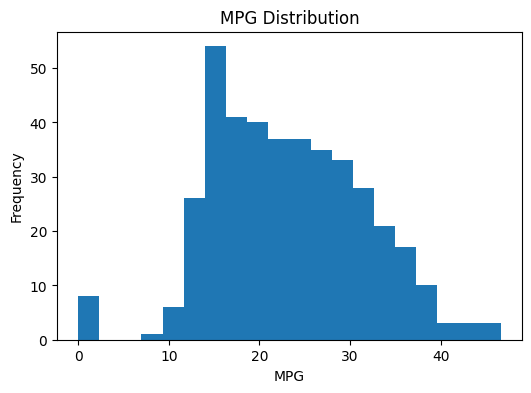

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df_cars["MPG"].dropna(), bins=20)
plt.title("MPG Distribution")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()


However, this does not make much sense as there isn't MPG equal to 0. How about we plot the MPG column and if it follows a random distribution we can use the mean of the column to compute the missing values. Otherwise, we can use the median (if there is a skewed normal distribution). However, there might be a better way of imputation which is getting the median or the mean of the MPG of the cars with similar attributes.

If we observe the graph above, we can consider it in a way or another normally distributed. Therefore, we can impute the missing values using the mean.

To compute the mean we need numeric values. However the values in the dataframe are objects. Therefore, we need to change them to numerics so that we can compute them.

Now let's see what is the mean of the MPG column

We can use this mean to compute the missing values since the graph demonstarted a normal distribution

In [30]:
# Convert MPG column to numeric values
df_cars["MPG"] = pd.to_numeric(df_cars["MPG"], errors="coerce")

df_cars.dtypes


Car                 str
MPG             float64
Cylinders           str
Displacement        str
Horsepower          str
Weight              str
Acceleration        str
Model               str
Origin              str
dtype: object

In [31]:
# Compute the mean of the MPG column
mpg_mean = df_cars["MPG"].mean()

mpg_mean


np.float64(23.096277915632754)

In [32]:
# Fill missing MPG values using the mean
df_cars_mean_imputed = df_cars.copy()
df_cars_mean_imputed["MPG"] = df_cars_mean_imputed["MPG"].fillna(mpg_mean)

df_cars_mean_imputed.head()


,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
0,Chevrolet Chevelle Malibu,23.096278,8,307.0,130.0,3504.,12.0,70,US
1,Buick Skylark 320,15.000000,8,350.0,NaN,3693.,11.5,70,US
2,Plymouth Satellite,23.096278,8,318.0,150.0,3436.,11.0,70,US
3,AMC Rebel SST,16.000000,8,NaN,150.0,NaN,12.0,70,US
4,Ford Torino,17.000000,8,302.0,140.0,3449.,10.5,70,US


### **Car Dataset - Simple Imputer**

*SimpleImputer* is a `scikit-learn` class which is helpful in handling the missing data in the predictive model dataset. It replaces the `NaN` values with a specified placeholder.
It is implemented by the use of the `SimpleImputer()` method which takes the following arguments :

`missing_values` : The missing_values placeholder which has to be imputed. By default is NaN

`strategy` : The data which will replace the NaN values from the dataset. The strategy argument can take the values – ‘mean'(default), ‘median’, ‘most_frequent’ and ‘constant’.


Let's start by importing the `SimpleImputer` into our notebook

What we need to do are two essential steps:

1. fit the data (compute the mean / median / most freq)
2. transform the data (place the computed values in the NaN cells)

In [33]:
# import SimpleImputer
from sklearn.impute import SimpleImputer


In [34]:
numeric_cols = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration"]


In [35]:
# Create the SimpleImputer using mean strategy
imputer = SimpleImputer(strategy="mean")

# Fit the imputer on numeric columns
df_cars_imputed_sklearn = df_cars.copy()
df_cars_imputed_sklearn[numeric_cols] = imputer.fit_transform(
    df_cars_imputed_sklearn[numeric_cols]
)

# Display the result
df_cars_imputed_sklearn.head()


,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
0,Chevrolet Chevelle Malibu,23.096278,8.0,307.000000,130.000000,3504.000000,12.0,70,US
1,Buick Skylark 320,15.000000,8.0,350.000000,103.143564,3693.000000,11.5,70,US
2,Plymouth Satellite,23.096278,8.0,318.000000,150.000000,3436.000000,11.0,70,US
3,AMC Rebel SST,16.000000,8.0,194.509877,150.000000,2978.293827,12.0,70,US
4,Ford Torino,17.000000,8.0,302.000000,140.000000,3449.000000,10.5,70,US


### Summary: Handling Missing Values with SimpleImputer

In this step, we handled missing values in the cars dataset using the `SimpleImputer` class from scikit-learn.

First, all columns were converted to numeric data types using `pd.to_numeric()` with `errors='coerce'`. This ensured that any non-numeric values were safely converted to `NaN`, allowing numerical operations to be applied consistently across the dataset.

Next, a `SimpleImputer` was initialized using the **mean strategy**. During the **fit** step, the imputer calculated the mean value for each column based on the available data. During the **transform** step, all missing (`NaN`) values were replaced with their corresponding column means.

Finally, the transformed output was converted back into a pandas DataFrame to preserve the original structure and column names. The resulting dataset is now free of missing values and suitable for further analysis or modeling.


## **Outlier Detection(Diabetes Dataset)** 


An Outlier is a data-item/object that deviates significantly from the rest of the (so-called normal)objects. They can be caused by measurement or execution errors. The analysis for outlier detection is referred to as outlier mining. There are many ways to detect the outliers, and the removal process is the data frame same as removing a data item from the panda’s data frame.



https://www.geeksforgeeks.org/detect-and-remove-the-outliers-using-python/





In [36]:
# Load the diabetes dataset from the CSV file
df_diabetes = pd.read_csv('../CSVs/diabetes.csv')

# Display the first few rows of the dataset
df_diabetes.head()

# Show basic statistical summary of the dataset
df_diabetes.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Outliers Visualization

#### Visualizing Outliers Using Box Plot
It captures the summary of the data effectively and efficiently with only a simple box and whiskers. Boxplot summarizes sample data using 25th, 50th, and 75th percentiles. One can just get insights(quartiles, median, and outliers) into the dataset by just looking at its boxplot.

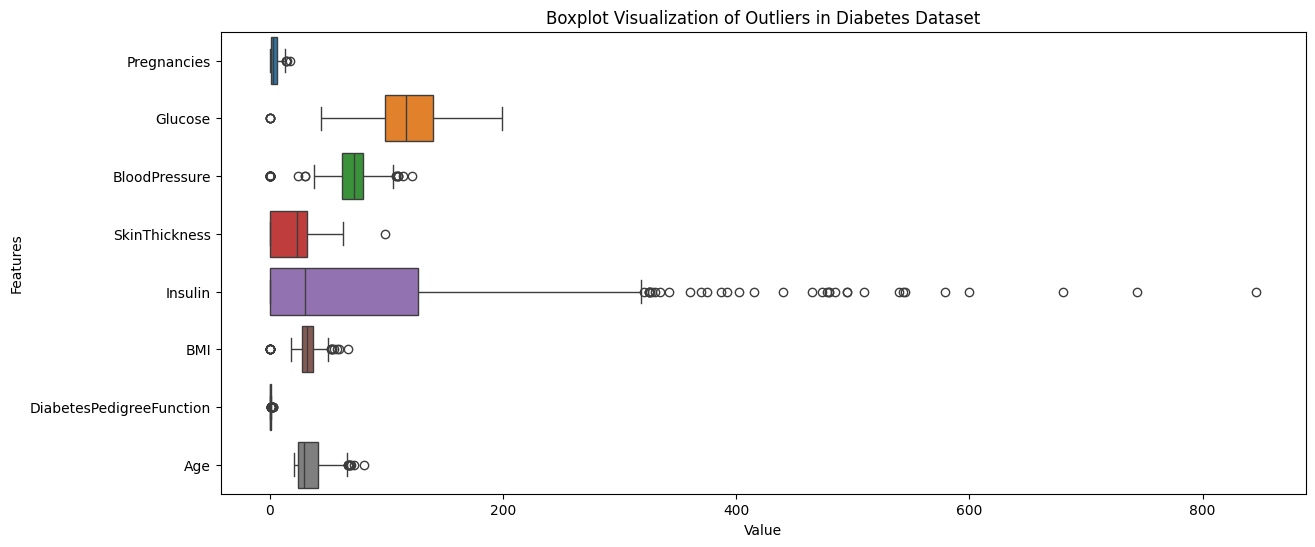

In [37]:
# Visualizing outliers using box plots for numerical features
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude the target variable
numeric_cols = df_diabetes.drop(columns=["Outcome"])

# Create boxplots for all numerical features
plt.figure(figsize=(14, 6))
sns.boxplot(data=numeric_cols, orient="h")

plt.title("Boxplot Visualization of Outliers in Diabetes Dataset")
plt.xlabel("Value")
plt.ylabel("Features")
plt.show()


The boxplot visualization shows that several features, especially Insulin and BMI,
contain significant outliers. 

#### Visualizing Outliers Using ScatterPlot.

It is used when you have paired numerical data and when your dependent variable has multiple values for each reading independent variable, or when trying to determine the relationship between the two variables. In the process of utilizing the scatter plot, one can also use it for outlier detection.

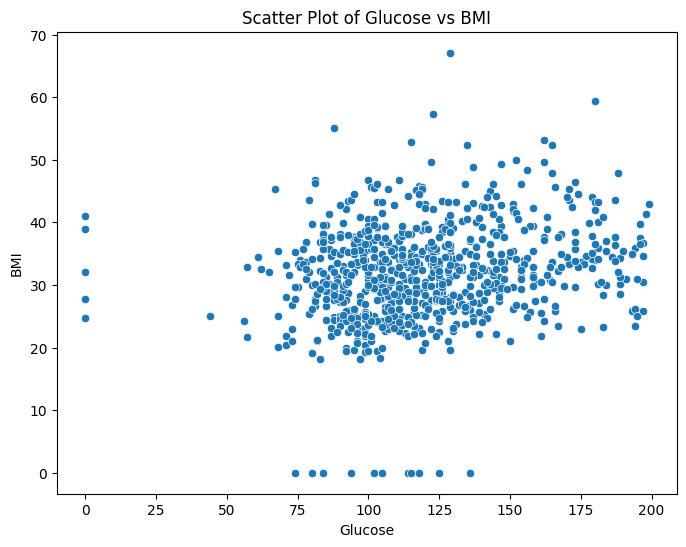

In [38]:
# Scatter plot to visualize outliers between two variables
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_diabetes,
    x="Glucose",
    y="BMI"
)

plt.title("Scatter Plot of Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()



The scatter plot visualizes the relationship between **Glucose** levels and **BMI** in the diabetes dataset.

Most data points are concentrated in a central region, indicating a typical range for the majority of patients.  
However, a few points are scattered far from the main cluster, especially at very high BMI or Glucose values. These points can be considered **potential outliers**.

#### Z-Score:
Z- Score is also called a standard score. This value/score helps to understand that how far is the data point from the mean. And after setting up a threshold value one can utilize z score values of data points to define the outliers.
<br>
Zscore = (data_point -mean) / std. deviation



In [39]:
# Import required library
from scipy import stats

# Select numerical columns (exclude target variable)
numeric_cols = df_diabetes.drop(columns=["Outcome"])



In [40]:
# Compute Z-scores for each numerical feature
z_scores = stats.zscore(numeric_cols)

# Convert to DataFrame for easier handling
z_scores_df = pd.DataFrame(
    z_scores,
    columns=numeric_cols.columns
)


In [41]:
# Define Z-score threshold
threshold = 3

# Identify outliers based on threshold
outliers = (z_scores_df.abs() > threshold)

# Count outliers per column
outlier_counts = outliers.sum()

outlier_counts


Pregnancies                  4
Glucose                      5
BloodPressure               35
SkinThickness                1
Insulin                     18
BMI                         14
DiabetesPedigreeFunction    11
Age                          5
dtype: int64

In [42]:
# Rows that contain at least one outlier
outlier_rows = df_diabetes[outliers.any(axis=1)]

outlier_rows.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137,40,35,168,43.1,2.288,33,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1
13,1,189,60,23,846,30.1,0.398,59,1


Now to define an outlier threshold value is chosen which is generally 3.0. As 99.7% of the data points lie between +/- 3 standard deviation (using Gaussian Distribution approach).

Rows where Z value is greater than 2

In [43]:
# Define Z-score threshold (as specified in the notebook)
threshold = 2


In [44]:
# Identify rows where any Z-score value exceeds the threshold
outliers_zscore = (z_scores_df.abs() > threshold)

# Extract rows containing outliers
outlier_rows_zscore = df_diabetes[outliers_zscore.any(axis=1)]

outlier_rows_zscore.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137,40,35,168,43.1,2.288,33,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1
12,10,139,80,0,0,27.1,1.441,57,0


In [45]:
print(f"Number of rows with Z-score outliers: {outlier_rows_zscore.shape[0]}")


Number of rows with Z-score outliers: 217


### Summary: Outlier Detection Using Z-Score

In this step, outliers in the diabetes dataset were identified using the **Z-score method**.
The Z-score measures how many standard deviations a data point is away from the mean and is
commonly used for detecting extreme values in approximately normally distributed data.

A threshold of **|Z| > 2** was applied in this analysis. Although a threshold of |Z| > 3 is often
used as a more conservative criterion, using |Z| > 2 allows for the identification of a broader
set of potential outliers during exploratory data analysis.

Z-scores were computed for all numerical features, and rows were flagged as outliers if **any**
feature in the row exceeded the defined threshold. As a result, **217 rows** were identified as
containing potential outliers.

At this stage, the detected outliers were **retained** for further analysis and visualization,
rather than being removed. This approach ensures that no potentially important data is discarded
prematurely and allows for informed decision-making in later stages of the analysis.


#### IQR (Inter-Quartile Range)
Inter Quartile Range approach to finding the outliers is the most commonly used and most trusted approach used in the research field. <Br>
IQR = Quartile3 - Quartile1

To define the outlier base value is defined above and below dataset’s normal range namely Upper and Lower bounds, define the upper and the lower bound (1.5*IQR value is considered) :<br>
upper = Q3 + 1.5 * IQR <br>
lower = Q1 - 1.5 * IQR <br> 

In [46]:
# Explicitly compute IQR upper and lower bounds

# Q1 and Q3 were computed previously
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)

# Inter-Quartile Range
IQR = Q3 - Q1

# Define upper and lower bounds using 1.5 * IQR rule
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

upper_bound, lower_bound


(Pregnancies                  13.500
 Glucose                     202.125
 BloodPressure               107.000
 SkinThickness                80.000
 Insulin                     318.125
 BMI                          50.550
 DiabetesPedigreeFunction      1.200
 Age                          66.500
 dtype: float64,
 Pregnancies                  -6.500
 Glucose                      37.125
 BloodPressure                35.000
 SkinThickness               -48.000
 Insulin                    -190.875
 BMI                          13.350
 DiabetesPedigreeFunction     -0.330
 Age                          -1.500
 dtype: float64)

Using the Inter-Quartile Range (IQR) method, the upper and lower bounds were calculated individually for each numerical feature in the dataset.

For each column:

Upper Bound was computed as:

𝑄
3
+
1.5
×
𝐼
𝑄
𝑅
Q3+1.5×IQR

Lower Bound was computed as:

𝑄
1
−
1.5
×
𝐼
𝑄
𝑅
Q1−1.5×IQR



- Removing the outliers:
For removing the outlier, one must follow the same process of removing an entry from the dataset using its exact position in the dataset because in all the above methods of detecting the outliers end result is the list of all those data items that satisfy the outlier definition according to the method used.

In [47]:
# Create a copy of the original dataset to preserve the raw data
# and allow comparison before and after outlier removal
df_original = df_diabetes.copy()


In [48]:
# IQR-based Outlier Removal for Glucose

# 1. Keep a copy of the original dataset (for comparison)
df_original = df_diabetes.copy()

# 2. Compute Q1, Q3, and IQR for the Glucose column
Q1 = df_diabetes['Glucose'].quantile(0.25)
Q3 = df_diabetes['Glucose'].quantile(0.75)
IQR = Q3 - Q1

# 3. Compute lower and upper bounds using the 1.5 * IQR rule
glucose_lower = Q1 - 1.5 * IQR
glucose_upper = Q3 + 1.5 * IQR

print(f"Glucose Q1: {Q1}")
print(f"Glucose Q3: {Q3}")
print(f"Glucose IQR: {IQR}")
print(f"Glucose Lower Bound: {glucose_lower}")
print(f"Glucose Upper Bound: {glucose_upper}")

# 4. Remove outliers based only on the Glucose feature
df_iqr_cleaned = df_diabetes[
    (df_diabetes['Glucose'] >= glucose_lower) &
    (df_diabetes['Glucose'] <= glucose_upper)
]

# 5. Compare dataset size before and after outlier removal
print(f"Rows before removing Glucose outliers: {df_original.shape[0]}")
print(f"Rows after removing Glucose outliers: {df_iqr_cleaned.shape[0]}")


Glucose Q1: 99.0
Glucose Q3: 140.25
Glucose IQR: 41.25
Glucose Lower Bound: 37.125
Glucose Upper Bound: 202.125
Rows before removing Glucose outliers: 768
Rows after removing Glucose outliers: 763


### Summary: Outlier Detection Using IQR

In this step, outliers were identified using the IQR (Interquartile Range) method.

First, Q1 (25th percentile) and Q3 (75th percentile) were calculated for each numerical feature. The IQR was computed as:

IQR = Q3 − Q1

Then, the lower and upper bounds were defined using the 1.5 × IQR rule:

Lower bound = Q1 − 1.5 × IQR

Upper bound = Q3 + 1.5 × IQR

Any values outside this range were considered potential outliers.

After computing the bounds, outliers were identified (and optionally removed for selected features like BMI). The dataset size before and after removal was compared to understand the impact of cleaning.

Overall, the IQR method provides a simple and reliable way to detect extreme values without being too sensitive to outliers.